In [1]:
import sys
sys.path.append('../../../')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

from scipy.stats import chi2, multivariate_normal

from LRM.plotting import set_plot_style
from LRM.CMP1D import CMP1D, SmoothedEmpiricalDensity1D, GoodTuringDensity1D, NPMLEEmpiricalBayesDensity1D

set_plot_style()

# Helpers

In [2]:
def transform_logtheta_theta(mu_X, Sigma_X):

    mu1, mu2 = mu_X.flatten()
    sigma11, sigma12 = Sigma_X[0, 0], Sigma_X[0, 1]
    sigma22 = Sigma_X[1, 1]

    # Compute E[theta1] = E[exp(x1)]
    E_theta1 = np.exp(mu1 + 0.5 * sigma11)

    # Mean vector
    mu_Y = np.array([
        E_theta1,
        mu2
    ])

    # Variance of exp(x1)
    var_theta1 = (np.exp(sigma11) - 1) * np.exp(2 * mu1 + sigma11)

    # Covariance between exp(x1) and x2
    cov_theta1_theta2 = np.exp(mu1 + 0.5 * sigma11) * sigma12

    # Covariance matrix
    Sigma_Y = np.array([
        [var_theta1,             cov_theta1_theta2],
        [cov_theta1_theta2,      sigma22]
    ])

    return mu_Y.reshape(-1,1), Sigma_Y


def transform_theta_logtheta(mu_X, Sigma_X):

    mu_X = np.asarray(mu_X)
    Sigma_X = np.asarray(Sigma_X)

    theta1, theta2 = mu_X
    if theta1 <= 0:
        raise ValueError("theta1 must be positive for log transformation.")

    # g(mu_X)
    mu_Y = np.array([np.log(theta1), theta2])

    # Jacobian of g at mu_X
    J = np.array([
        [1/theta1, 0],
        [0,        1]
    ])

    # Covariance after transformation
    Sigma_Y = J @ Sigma_X @ J.T

    return mu_Y.reshape(-1,1), Sigma_Y

In [3]:
def get_mean_cov(i, theta1, theta2, method):

    file = lambda method : f"./outputs/{method}_theta1={theta1}_theta2={theta2}_numboot=100_dnum=2000_pnum=5000_data=dataset{i}_samples.npy"
    post_sample = np.load(file(method))

    return post_sample.mean(axis=0), np.cov(post_sample.T)


In [4]:
def plot_gaussian_ellipse(mean, cov, ax, confidence=0.95, style='solid', label=None, color='black'):
    # Compute the ellipse corresponding to the confidence level
    chi2_val = chi2.ppf(confidence, df=2)
    
    # Eigen-decomposition for ellipse axes
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    
    # Compute width and height of ellipse
    width, height = 2 * np.sqrt(vals * chi2_val)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor=color, facecolor='none', linestyle=style, linewidth=1.7, label=label)
    ax.add_patch(ellipse)

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import multivariate_normal, chi2

# ----- Data -----
data_full = np.load("./outputs/dataset2_theta1=4.0_theta2=1.25.npy").flatten()

n_vals = [100, 500, 1000]
rng = np.random.default_rng(1)

prior = multivariate_normal(mean=[3.0, 3.0], cov=[[1.0, 0.0], [0.0, 1.0]])
prior_mean, prior_cov = transform_theta_logtheta(prior.mean, prior.cov)

results = {}

for n in n_vals:
    idx = rng.choice(len(data_full), size=n, replace=False)
    data_n = data_full[idx]

    # ---- Laplace-smoothed empirical ----
    emp_lap = SmoothedEmpiricalDensity1D(alpha=1.0).fit(data_n)
    cmp_lap = CMP1D(empirical=emp_lap)

    beta_lap, cov_lap_calib, _ = cmp_lap.fit_coverage(
        data=data_n,
        prior_mean=prior_mean,
        prior_cov=prior_cov,
        verbose=True,
        B=50,
    )

    post_lap = cmp_lap.posterior(
        data_n,
        beta=beta_lap,
        mu_prior=prior_mean,
        Sigma_prior=prior_cov,
    )

    mean_lap, cov_lap = transform_logtheta_theta(
        post_lap.mean,
        post_lap.cov,
    )

    # ---- Good--Turing truncated empirical ----
    emp_gt = GoodTuringDensity1D(max_val=20).fit(data_n)
    cmp_gt = CMP1D(empirical=emp_gt)

    beta_gt, cov_gt_calib, _ = cmp_gt.fit_coverage(
        data=data_n,
        prior_mean=prior_mean,
        prior_cov=prior_cov,
        verbose=True,
        B=100,
    )

    post_gt = cmp_gt.posterior(
        data_n,
        beta=beta_gt,
        mu_prior=prior_mean,
        Sigma_prior=prior_cov,
    )

    mean_gt, cov_gt = transform_logtheta_theta(
        post_gt.mean,
        post_gt.cov,
    )

    # ---- NPMLE empirical-Bayes ----
    emp_npmle = NPMLEEmpiricalBayesDensity1D(
        max_val=20,
        grid_size=100,
        max_iter=1000,
        tol=1e-8,
        verbose=False,
    ).fit(data_n)

    cmp_npmle = CMP1D(empirical=emp_npmle)

    beta_npmle, cov_npmle_calib, _ = cmp_npmle.fit_coverage(
        data=data_n,
        prior_mean=prior_mean,
        prior_cov=prior_cov,
        verbose=True,
        B=100,
    )

    post_npmle = cmp_npmle.posterior(
        data_n,
        beta=beta_npmle,
        mu_prior=prior_mean,
        Sigma_prior=prior_cov,
    )

    mean_npmle, cov_npmle = transform_logtheta_theta(
        post_npmle.mean,
        post_npmle.cov,
    )

    # ---- Store results ----
    results[n] = {
        "data": data_n,

        "mean_lap": mean_lap,
        "cov_lap": cov_lap,
        "beta_lap": beta_lap,
        "cov_lap_calib": cov_lap_calib,

        "mean_gt": mean_gt,
        "cov_gt": cov_gt,
        "beta_gt": beta_gt,
        "cov_gt_calib": cov_gt_calib,

        "mean_npmle": mean_npmle,
        "cov_npmle": cov_npmle,
        "beta_npmle": beta_npmle,
        "cov_npmle_calib": cov_npmle_calib,
    }

[scipy] beta*: 0.398727, coverage: 0.9400 (target 0.9500); fun=0.0001, success=True
[scipy] beta*: 0.200278, coverage: 0.9500 (target 0.9500); fun=0, success=True
[scipy] beta*: 0.0959853, coverage: 0.9500 (target 0.9500); fun=0, success=True
[scipy] beta*: 0.345843, coverage: 1.0000 (target 0.9500); fun=0.0025, success=True
[scipy] beta*: 0.329936, coverage: 0.9600 (target 0.9500); fun=0.0001, success=True
[scipy] beta*: 0.198292, coverage: 0.9500 (target 0.9500); fun=0, success=True
[scipy] beta*: 0.730778, coverage: 0.9400 (target 0.9500); fun=0.0001, success=True
[scipy] beta*: 0.531568, coverage: 0.9500 (target 0.9500); fun=0, success=True
[scipy] beta*: 0.368888, coverage: 0.9500 (target 0.9500); fun=0, success=True


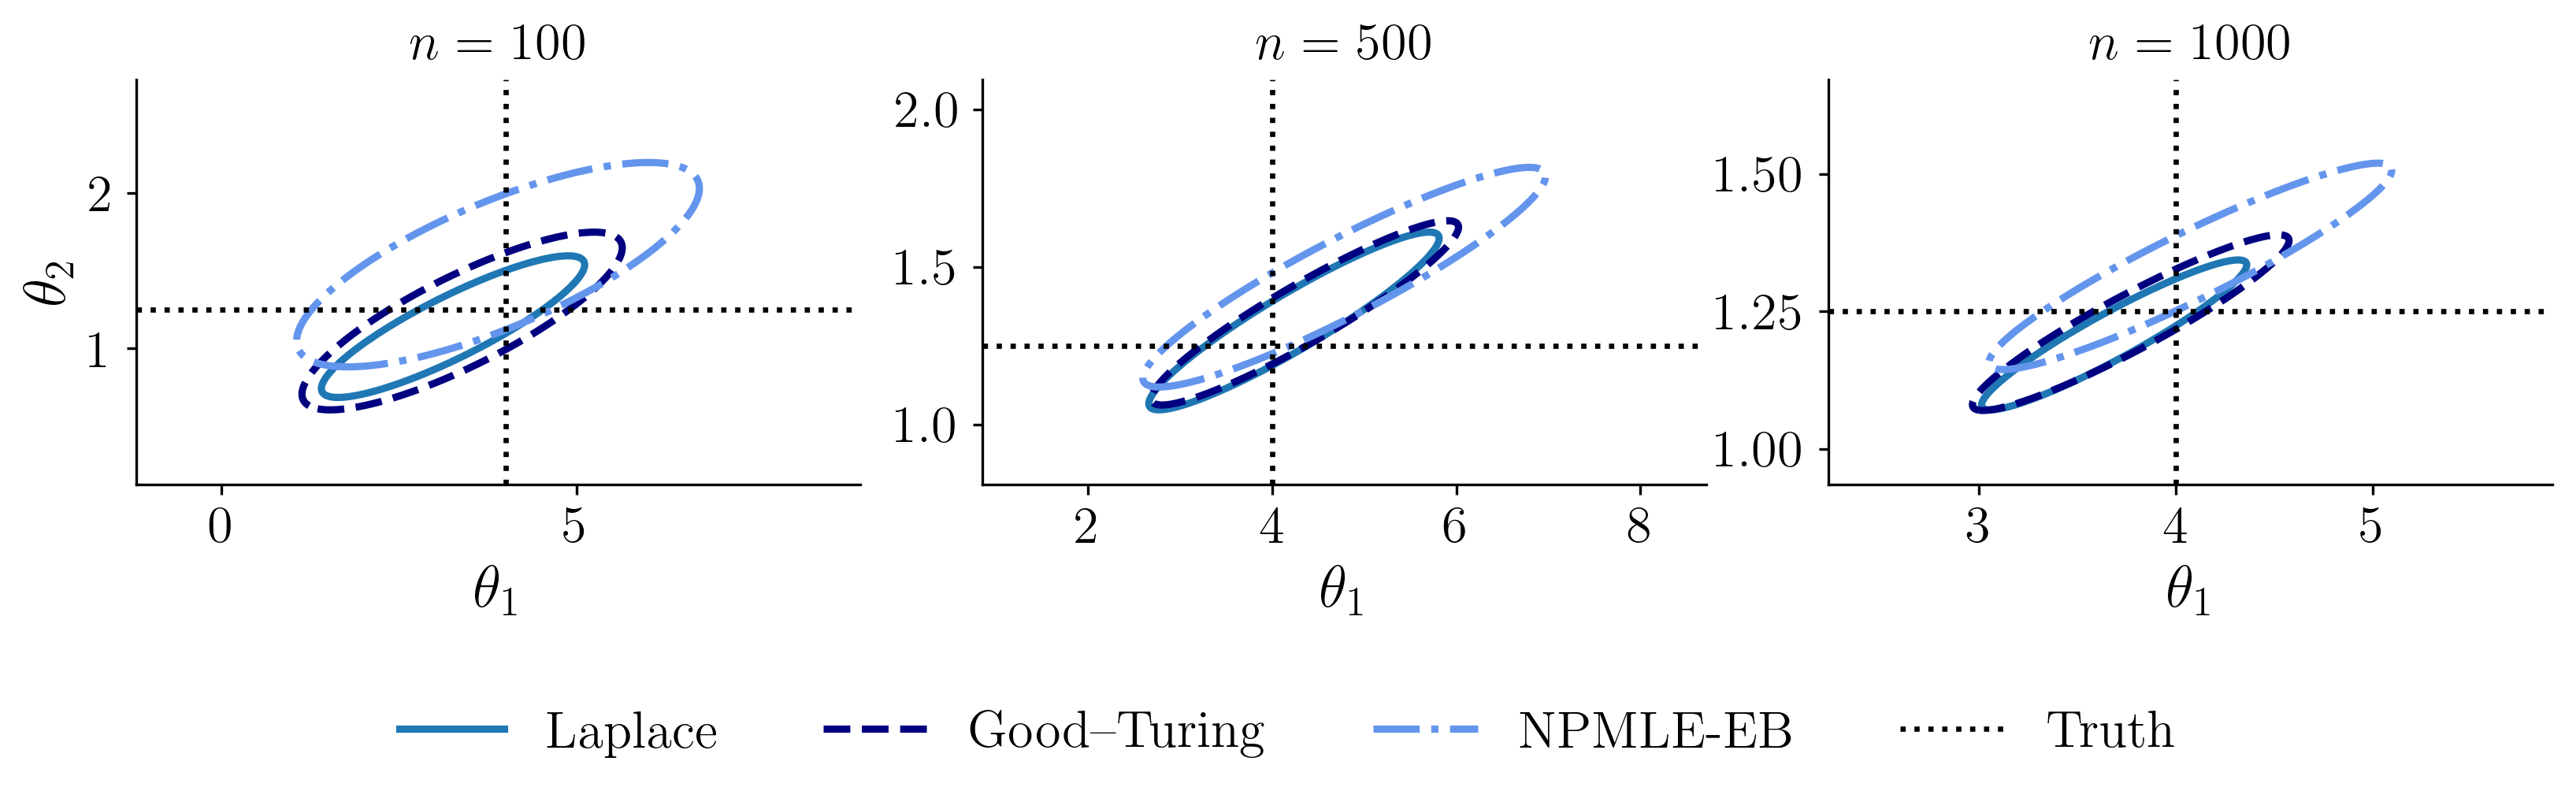

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharex=False, sharey=False)

q95 = chi2.ppf(0.95, df=2)

blue_lap = "tab:blue"
blue_gt = "navy"
blue_npmle = "cornflowerblue"
truth_color = "black"

theta_true = np.array([4.0, 1.25])

for ax, n in zip(axes, n_vals):
    mean_lap = np.asarray(results[n]["mean_lap"], dtype=float).ravel()
    mean_gt = np.asarray(results[n]["mean_gt"], dtype=float).ravel()
    mean_npmle = np.asarray(results[n]["mean_npmle"], dtype=float).ravel()

    cov_lap = np.asarray(results[n]["cov_lap"], dtype=float).reshape(2, 2)
    cov_gt = np.asarray(results[n]["cov_gt"], dtype=float).reshape(2, 2)
    cov_npmle = np.asarray(results[n]["cov_npmle"], dtype=float).reshape(2, 2)

    means = np.vstack([mean_lap, mean_gt, mean_npmle, theta_true])
    sds = np.vstack([
        np.sqrt(np.diag(cov_lap)),
        np.sqrt(np.diag(cov_gt)),
        np.sqrt(np.diag(cov_npmle)),
        np.zeros(2),
    ])

    x_min = np.min(means[:, 0] - 4 * sds[:, 0])
    x_max = np.max(means[:, 0] + 4 * sds[:, 0])
    y_min = np.min(means[:, 1] - 4 * sds[:, 1])
    y_max = np.max(means[:, 1] + 4 * sds[:, 1])

    x_pad = 0.05 * (x_max - x_min)
    y_pad = 0.05 * (y_max - y_min)
    x_min, x_max = x_min - x_pad, x_max + x_pad
    y_min, y_max = y_min - y_pad, y_max + y_pad

    xx = np.linspace(x_min, x_max, 300)
    yy = np.linspace(y_min, y_max, 300)
    X, Y = np.meshgrid(xx, yy)
    pos = np.dstack((X, Y))

    rv_lap = multivariate_normal(mean=mean_lap, cov=cov_lap)
    rv_gt = multivariate_normal(mean=mean_gt, cov=cov_gt)
    rv_npmle = multivariate_normal(mean=mean_npmle, cov=cov_npmle)

    Z_lap = rv_lap.pdf(pos)
    Z_gt = rv_gt.pdf(pos)
    Z_npmle = rv_npmle.pdf(pos)

    level_lap = rv_lap.pdf(mean_lap) * np.exp(-0.5 * q95)
    level_gt = rv_gt.pdf(mean_gt) * np.exp(-0.5 * q95)
    level_npmle = rv_npmle.pdf(mean_npmle) * np.exp(-0.5 * q95)

    ax.contour(
        X, Y, Z_lap,
        levels=[level_lap],
        linewidths=2.2,
        colors=[blue_lap],
    )

    ax.contour(
        X, Y, Z_gt,
        levels=[level_gt],
        linewidths=2.2,
        linestyles="--",
        colors=[blue_gt],
    )

    ax.contour(
        X, Y, Z_npmle,
        levels=[level_npmle],
        linewidths=2.2,
        linestyles="-.",
        colors=[blue_npmle],
    )

    ax.axvline(theta_true[0], linestyle=":", linewidth=1.6, color=truth_color)
    ax.axhline(theta_true[1], linestyle=":", linewidth=1.6, color=truth_color)

    ax.set_title(rf"$n={n}$", fontsize=16)
    ax.set_xlabel(r"$\theta_1$", fontsize=18)
    ax.tick_params(axis="both", labelsize=16)

axes[0].set_ylabel(r"$\theta_2$", fontsize=18)

lap_handle = mlines.Line2D(
    [], [], linestyle="-", linewidth=2.2, color=blue_lap, label="Laplace"
)

gt_handle = mlines.Line2D(
    [], [], linestyle="--", linewidth=2.2, color=blue_gt, label="Good--Turing"
)

npmle_handle = mlines.Line2D(
    [], [], linestyle="-.", linewidth=2.2, color=blue_npmle, label="NPMLE-EB"
)

truth_handle = mlines.Line2D(
    [], [], linestyle=":", linewidth=1.6, color=truth_color, label="Truth"
)

fig.legend(
    handles=[lap_handle, gt_handle, npmle_handle, truth_handle],
    frameon=False,
    fontsize=16,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.08),
)

plt.tight_layout(rect=[0, 0.12, 1, 1])


plt.savefig("./results/CMP-univariate-vary-q-estimator.pdf", format="pdf", bbox_inches='tight')